# Customer Segmentation Model — Financial Health & Engagement

**Dataset:** Consumer Financial Health & Engagement 2025 (synthetic, Vietnam) — 999 consumers × up to 12 months, customer-month grain, joined on `consumer_id`. Also uses `consumer_transactions_2025.csv` (transaction-level rhythm features, Section 1.6).

**Goal:** Build a customer segmentation model spanning financial health and engagement, validate it, and profile the resulting segments clearly enough for business to act on.

*Restructure notes on this version:* all data cleaning — including the transaction-level rhythm features and the handling of customers with no transaction records — now happens in Section 1, **before** k is chosen and before any clustering (Section 2). Segment visualizations are annotated directly with cluster order/name. Post-segmentation analysis stays descriptive (profiling for business clarity); business recommendations were removed per current scope — only limitations and future-improvement directions are discussed (Section 5).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

## 1. Data Preprocessing & Feature Engineering

### 1.1 Load and inspect the customer-month data

In [2]:
df = pd.read_csv("consumer_financial_health_engagement_2025.csv", parse_dates=["analysis_month"])
df = df.sort_values(["consumer_id", "analysis_month"])
print("Shape:", df.shape)
print("Unique consumers:", df['consumer_id'].nunique())
print("Months per consumer:")
print(df.groupby('consumer_id').size().describe())
print("\nMissing values:")
print(df.isna().sum()[df.isna().sum() > 0])

Shape: (10992, 30)
Unique consumers: 999
Months per consumer:
count    999.000000
mean      11.003003
std        3.151643
min        1.000000
25%       12.000000
50%       12.000000
75%       12.000000
max       12.000000
dtype: float64

Missing values:
next_month_low_health_flag    999
dtype: int64


`next_month_low_health_flag` is the only column with missing values — it's `NaN` by design for each customer's final observed month (there is no "next month" to evaluate). Every other field has 100% coverage across all 10,992 customer-month rows.

### 1.2 Aggregate customer-month data to one row per customer

Segmentation is done at the customer level, so monthly metrics are averaged across each customer's history. Two features are engineered:
- **`balance_trend_norm`** = (last ending balance − first opening balance) ÷ average monthly income — a normalized measure of balance trajectory over the year.
- **`low_health_rate`** = share of months flagged as low-health next month (kept aside for *validation*, not used as a clustering input, to avoid circularity).

In [3]:
latest = df.groupby("consumer_id").tail(1).set_index("consumer_id")[
    ["age", "gender", "occupation", "province_city"]
]
first_bal = df.groupby("consumer_id").head(1).set_index("consumer_id")["opening_balance_vnd"]
last_bal = df.groupby("consumer_id").tail(1).set_index("consumer_id")["ending_balance_vnd"]
avg_income_s = df.groupby("consumer_id")["monthly_income_vnd"].mean()
balance_trend_norm = ((last_bal - first_bal) / avg_income_s).rename("balance_trend_norm")

agg = df.groupby("consumer_id").agg(
    n_months=("analysis_month", "count"),
    avg_income=("monthly_income_vnd", "mean"),
    avg_essential_ratio=("essential_spend_ratio", "mean"),
    avg_online_ratio=("online_spend_ratio", "mean"),
    avg_spend_income_ratio=("spend_to_income_ratio", "mean"),
    avg_utilization=("credit_utilization_ratio", "mean"),
    avg_volatility=("spending_volatility", "mean"),
    avg_txn_count=("transaction_count", "mean"),
    avg_active_days=("active_transaction_days", "mean"),
    avg_recency=("transaction_recency_days", "mean"),
    avg_engagement_score=("engagement_score", "mean"),
    avg_health_score=("financial_health_score", "mean"),
    low_health_rate=("next_month_low_health_flag", "mean"),
)
cust = agg.join(latest).join(balance_trend_norm)
cust["low_health_rate"] = cust["low_health_rate"].fillna(0)
print("Customer-level table:", cust.shape, "| missing values:", cust.isna().sum().sum())
cust.head(3)

Customer-level table: (999, 18) | missing values: 0


,n_months,avg_income,avg_essential_ratio,avg_online_ratio,avg_spend_income_ratio,avg_utilization,avg_volatility,avg_txn_count,avg_active_days,avg_recency,avg_engagement_score,avg_health_score,low_health_rate,age,gender,occupation,province_city,balance_trend_norm
consumer_id,,,,,,,,,,,,,,,,,,
KH00100010,12,9.888958e+08,0.381114,0.167251,0.591550,0.155108,0.919464,243.500000,30.333333,0.000000,78.291667,70.616667,0.0,27,Nam,Kỹ sư sản xuất,Đồng Nai,4.884369
KH00100045,12,3.393067e+08,0.476878,0.191602,0.624583,0.143142,1.444694,122.333333,29.416667,0.166667,77.425000,68.483333,0.0,62,Nữ,Chuyên viên sinh lý vận động,Nghệ An,4.516098
KH00100050,12,2.515875e+08,0.504853,0.216247,0.792517,0.299525,1.359126,122.333333,29.666667,0.000000,78.700000,60.958333,0.0,81,Nữ,Nhà thiết kế dệt may,Cần Thơ,2.498383


### 1.3 Candidate features for the two dimensions

Deliberately *not* the dataset's own `engagement_score`/`financial_health_score`, so the segmentation can be built independently and cross-checked against them later.

| Financial health dimension | Engagement dimension |
|---|---|
| `avg_spend_income_ratio` | `avg_txn_count` |
| `avg_utilization` | `avg_active_days` |
| `avg_essential_ratio` | `avg_online_ratio` (inverted) |
| `avg_volatility` | `avg_recency` (inverted) |
| `balance_trend_norm` | |

### 1.4 Fine-tuning: redundancy, skew and outlier checks

Three things K-Means is sensitive to, checked explicitly before modeling:
1. **Redundant/correlated features** — Euclidean distance implicitly *double-weights* any signal repeated across two correlated columns.
2. **Skewed / zero-inflated features** — a few extreme values can pull a centroid away from where most customers actually sit.
3. **Scale** — handled by z-score standardization, but only meaningful once (1) and (2) are addressed.

In [4]:
def winsorize(s, lo=0.01, hi=0.99):
    a, b = s.quantile(lo), s.quantile(hi)
    return s.clip(a, b)

cust["avg_recency_log"] = np.log1p(cust["avg_recency"])
cust["avg_online_ratio_log"] = np.log1p(cust["avg_online_ratio"])
for f in ["avg_spend_income_ratio", "avg_utilization", "avg_essential_ratio", "avg_volatility", "balance_trend_norm"]:
    cust[f + "_w"] = winsorize(cust[f])

fin_features = ["avg_spend_income_ratio_w", "avg_utilization_w", "avg_essential_ratio_w",
                "avg_volatility_w", "balance_trend_norm_w"]
eng_features = ["avg_txn_count", "avg_active_days", "avg_online_ratio_log", "avg_recency_log"]

print("Skewness after log/winsorize fixes:")
print(cust[fin_features + eng_features].skew().round(2))
print("\nMax |correlation| among selected features:",
      round(cust[fin_features + eng_features].corr().abs().where(
          ~np.eye(len(fin_features+eng_features), dtype=bool)).max().max(), 3))

Skewness after log/winsorize fixes:
avg_spend_income_ratio_w    0.09
avg_utilization_w           0.48
avg_essential_ratio_w      -2.03
avg_volatility_w            0.07
balance_trend_norm_w       -0.01
avg_txn_count               0.40
avg_active_days            -2.56
avg_online_ratio_log        2.82
avg_recency_log             3.26
dtype: float64

Max |correlation| among selected features: 0.916


### 1.5 Composite indices (for interpretation/visualization)

z-score each feature (sign-flipped where "higher is worse"), average per dimension, rescale to 0–100.

In [5]:
fin_direction = {"avg_spend_income_ratio_w": False, "avg_utilization_w": False,
                  "avg_essential_ratio_w": False, "avg_volatility_w": False, "balance_trend_norm_w": True}
eng_direction = {"avg_txn_count": True, "avg_active_days": True,
                  "avg_online_ratio_log": True, "avg_recency_log": False}

def zscore_index(frame, feats, direction):
    z = pd.DataFrame(index=frame.index)
    for f in feats:
        zc = (frame[f] - frame[f].mean()) / frame[f].std()
        z[f] = zc if direction[f] else -zc
    return z.mean(axis=1)

def to_100(s):
    return (s - s.min()) / (s.max() - s.min()) * 100

cust["FinancialHealthIndex"] = to_100(zscore_index(cust, fin_features, fin_direction))
cust["EngagementIndex"] = to_100(zscore_index(cust, eng_features, eng_direction))

print("Corr(FHI, given financial_health_score):", round(cust['FinancialHealthIndex'].corr(cust['avg_health_score']), 3))
print("Corr(EI, given engagement_score):       ", round(cust['EngagementIndex'].corr(cust['avg_engagement_score']), 3))

Corr(FHI, given financial_health_score): 0.801
Corr(EI, given engagement_score):        0.916


### 1.6 Transaction rhythm features — and handling customers with no transaction records

**Moved here deliberately (before Section 2/model selection).** Any new feature block and any data-quality fix belongs in preprocessing, finished *before* k is chosen — choosing k on an incomplete feature set and patching data issues afterward risks re-litigating a decision that was never based on the final data in the first place.

**Data-quality warning found in `consumer_transactions_2025.csv`:**
1. The file is truncated at exactly row 1,048,576 — Excel's row limit. The case study describes 1,852,394 transactions for the full year, but this file has only ~1.05M rows, and `transaction_month` only runs 1–8 (not 1–12). The file has clearly been opened/saved in Excel at least once. **Consequence: 33/999 customers (who only transacted from month 9 onward) are completely absent from this file.**
2. `activity_datetime` has been reformatted by Excel into `mm:ss.0` — the real date/time is unrecoverable, so *daily* recency features can't be built from this file; only month/day-of-week/hour survive intact.

Given the truncation, only **day-of-week / hour rhythm features** are trustworthy (they don't depend on which months are present); month-level "gap between transactions" features are computed for documentation but **not** used as model input, since 908/966 present customers show all 8/8 available months active — near-zero variance that's an artifact of the cut, not real behavior.

In [6]:
tx = pd.read_csv("consumer_transactions_2025.csv",
                  usecols=["consumer_id", "transaction_month", "transaction_day_of_week", "transaction_hour"],
                  dtype={"transaction_month": "int8", "transaction_day_of_week": "int8", "transaction_hour": "int8"})
print("Transaction rows read:", len(tx))
print("Customers present in transaction file:", tx["consumer_id"].nunique(), "/ 999")
print("Month range in file:", tx["transaction_month"].min(), "-", tx["transaction_month"].max(), "(expected 1-12)")

def rhythm_stats(g):
    dow, hr = g["transaction_day_of_week"], g["transaction_hour"]
    return pd.Series({
        "weekend_ratio": dow.isin([5, 6]).mean(),
        "night_ratio": ((hr >= 22) | (hr < 6)).mean(),
        "hour_mean": hr.mean(),
        "hour_std": hr.std(),
        "dow_nunique": dow.nunique(),
    })

rhythm_feats = tx.groupby("consumer_id").apply(rhythm_stats)
print("\nRhythm features computed for:", rhythm_feats.shape[0], "customers")

Transaction rows read: 1048575
Customers present in transaction file: 966 / 999
Month range in file: 1 - 8 (expected 1-12)

Rhythm features computed for: 966 customers


/tmp/ipykernel_2174/2094578960.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rhythm_feats = tx.groupby("consumer_id").apply(rhythm_stats)


**Handling the 33 customers with no transaction records — done now, before k is chosen or any clustering happens:** this is missing data caused by the Excel truncation, not a real customer behavior (a customer with genuinely zero transactions would already show `avg_txn_count = 0` in the main dataset, which is a different, already-handled case). Filled with the sample median and flagged via `missing_txn_data`, so this group can be identified or excluded later rather than silently modeled as "an average customer."

In [7]:
cust = cust.join(rhythm_feats)
missing_txn_mask = cust["weekend_ratio"].isna()
print("Customers with no transaction record (truncated out of the file):", missing_txn_mask.sum())

rhythm_cols = ["weekend_ratio", "night_ratio", "hour_mean", "hour_std", "dow_nunique"]
for c in rhythm_cols:
    cust[c] = cust[c].fillna(cust[c].median())
cust["missing_txn_data"] = missing_txn_mask.astype(int)

print("\nSkewness of raw rhythm features:")
print(cust[rhythm_cols].skew().round(2))

Customers with no transaction record (truncated out of the file): 33

Skewness of raw rhythm features:
weekend_ratio    1.91
night_ratio      3.34
hour_mean        0.78
hour_std         1.99
dow_nunique     -3.79
dtype: float64


Same fine-tuning checks as Section 1.4: `night_ratio` (skew≈3.3) and `weekend_ratio` (skew≈1.9) are right-skewed ratios → `log1p`; `hour_std` has a handful of extreme values → winsorize; `hour_mean` and `dow_nunique` are left as-is (bounded, no real outlier risk). Cross-checked against the already-selected fin/eng features: the highest correlations are `dow_nunique` vs `avg_active_days` (r≈0.76) and `night_ratio` vs `avg_active_days` (r≈−0.74) — real behavioral overlap, not near-duplication (nothing exceeds the r=0.95 near-duplicate threshold from Section 1.4), so nothing is dropped.

In [8]:
cust["weekend_ratio_log"] = np.log1p(cust["weekend_ratio"])
cust["night_ratio_log"] = np.log1p(cust["night_ratio"])
cust["hour_std_w"] = winsorize(cust["hour_std"])
rhythm_features = ["weekend_ratio_log", "night_ratio_log", "hour_mean", "hour_std_w", "dow_nunique"]

print("Skew after fine-tuning:", cust[rhythm_features].skew().round(2).to_dict())
print("\nMax |correlation| of each rhythm feature vs. existing fin/eng features:")
corr_check = cust[rhythm_features + fin_features + eng_features].corr()
print(corr_check.loc[rhythm_features, fin_features + eng_features].abs().max(axis=1).round(3))

Skew after fine-tuning: {'weekend_ratio_log': -0.22, 'night_ratio_log': 3.05, 'hour_mean': 0.78, 'hour_std_w': 3.42, 'dow_nunique': -3.79}

Max |correlation| of each rhythm feature vs. existing fin/eng features:
weekend_ratio_log    0.165
night_ratio_log      0.729
hour_mean            0.361
hour_std_w           0.642
dow_nunique          0.759
dtype: float64


## 2. Model Selection, Setup, Implementation & Validation

### 2.1 PCA within each dimension

Features within a block are still moderately correlated (expected). Instead of dropping more of them, **PCA is applied separately within each block** so K-Means clusters on a small number of *orthogonal* components rather than raw, correlated features.

In [9]:
def prep_block(frame, feats, direction=None):
    z = pd.DataFrame(index=frame.index)
    for f in feats:
        zc = (frame[f] - frame[f].mean()) / frame[f].std()
        z[f] = zc if (direction is None or direction[f]) else -zc
    return z

fin_z = prep_block(cust, fin_features, fin_direction)
eng_z = prep_block(cust, eng_features, eng_direction)
rhythm_z = prep_block(cust, rhythm_features)  # no "good/bad" direction -- not a health/engagement index

for name, z in [("Financial", fin_z), ("Engagement", eng_z), ("Rhythm", rhythm_z)]:
    p = PCA(random_state=42).fit(z)
    print(f"{name} block — explained variance ratio: {np.round(p.explained_variance_ratio_, 3)}")
    print(f"{name} block — cumulative:               {np.round(np.cumsum(p.explained_variance_ratio_), 3)}\n")

Financial block — explained variance ratio: [0.477 0.343 0.096 0.067 0.017]
Financial block — cumulative:               [0.477 0.82  0.916 0.983 1.   ]

Engagement block — explained variance ratio: [0.769 0.167 0.05  0.013]
Engagement block — cumulative:               [0.769 0.937 0.987 1.   ]

Rhythm block — explained variance ratio: [0.562 0.222 0.185 0.026 0.005]
Rhythm block — cumulative:               [0.562 0.784 0.969 0.995 1.   ]



Financial keeps 2 components (82%), Engagement keeps 2 (94%), Rhythm keeps 3 (97%) — each block's own natural threshold, not a fixed number chosen in advance.

In [10]:
pca_fin = PCA(n_components=2, random_state=42)
pca_eng = PCA(n_components=2, random_state=42)
pca_rhythm = PCA(n_components=3, random_state=42)
fin_pcs = pca_fin.fit_transform(fin_z)
eng_pcs = pca_eng.fit_transform(eng_z)
rhythm_pcs = pca_rhythm.fit_transform(rhythm_z)

### 2.2 Balancing blocks of different size (fin=2, eng=2, rhythm=3 dimensions)

Earlier fine-tuning (Section 2.2b in previous iterations) re-standardized combined PCA components to unit variance so no *single component* silently dominates. That worked by coincidence when both blocks had exactly 2 components each (2 vs 2 = already balanced). It stops working once a 3rd block of a *different* size joins: standardizing every column to unit variance still leaves the rhythm block contributing 3 units of total variance to the Euclidean distance vs. 2 units each for financial/engagement — the block with more retained components silently gets more influence purely because it has more columns, not because it carries more signal.

**Fix:** standardize each block's components to unit variance individually, then divide the whole block by `sqrt(number of components in that block)` — this makes every block contribute exactly 1 unit of total variance regardless of how many components it needed, a proper generalization of the earlier 2-vs-2 fix to blocks of unequal size.

In [11]:
def block_normalize(pcs):
    z = StandardScaler().fit_transform(pcs)
    return z / np.sqrt(z.shape[1])  # total block variance = 1, independent of block width

fin_b = block_normalize(fin_pcs)
eng_b = block_normalize(eng_pcs)
rhythm_b = block_normalize(rhythm_pcs)

X_final = np.hstack([fin_b, eng_b])                    # official model: financial + engagement only
X_with_rhythm = np.hstack([fin_b, eng_b, rhythm_b])     # candidate extension, tested below

print("Per-block total variance (should all read ~1.0):")
print("  financial:", round(fin_b.var(axis=0).sum(), 3),
      " engagement:", round(eng_b.var(axis=0).sum(), 3),
      " rhythm:", round(rhythm_b.var(axis=0).sum(), 3))

Per-block total variance (should all read ~1.0):
  financial: 1.0  engagement: 1.0  rhythm: 1.0


### 2.3 Choosing k — and testing whether the rhythm block earns a seat in the official model

Both questions are answered together, on the **complete**, properly weighted feature set (financial + engagement, with the rhythm block tested as a candidate addition) — this is the "choose k" step, and it now happens *after* all Section 1 data prep is finished, rhythm block included.

k=2  silhouette financial+engagement=0.5837   +rhythm block=0.5966
k=3  silhouette financial+engagement=0.3312   +rhythm block=0.2698
k=4  silhouette financial+engagement=0.3357   +rhythm block=0.2830
k=5  silhouette financial+engagement=0.3242   +rhythm block=0.2665
k=6  silhouette financial+engagement=0.3173   +rhythm block=0.2785
k=7  silhouette financial+engagement=0.3005   +rhythm block=0.2549
k=8  silhouette financial+engagement=0.3163   +rhythm block=0.2447


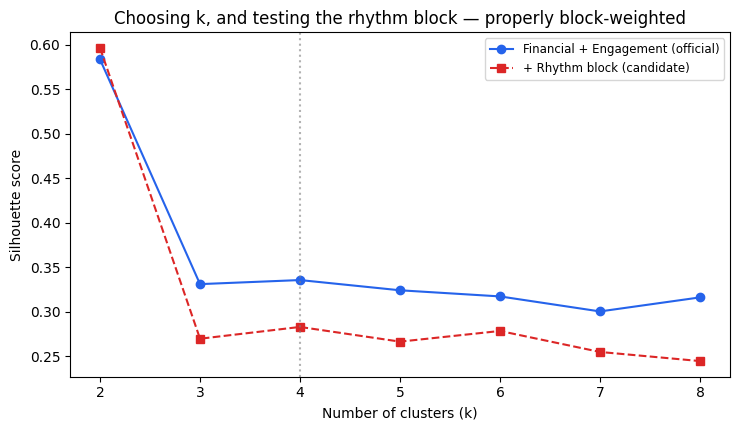


Cluster sizes at k=4 WITH rhythm block: [561  23  67 348]
Cluster sizes at k=4 WITHOUT rhythm block: [304  88 247 360]


In [12]:
ks = list(range(2, 9))
sils_final, sils_with_rhythm = [], []
for k in ks:
    labels_final = KMeans(n_clusters=k, n_init=20, random_state=42).fit_predict(X_final)
    labels_rhythm = KMeans(n_clusters=k, n_init=20, random_state=42).fit_predict(X_with_rhythm)
    sils_final.append(silhouette_score(X_final, labels_final))
    sils_with_rhythm.append(silhouette_score(X_with_rhythm, labels_rhythm))
    print(f"k={k}  silhouette financial+engagement={sils_final[-1]:.4f}   +rhythm block={sils_with_rhythm[-1]:.4f}")

fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.plot(ks, sils_final, 'o-', color='#2563eb', label='Financial + Engagement (official)')
ax.plot(ks, sils_with_rhythm, 's--', color='#dc2626', label='+ Rhythm block (candidate)')
ax.axvline(4, color='gray', linestyle=':', alpha=0.6)
ax.set_xlabel('Number of clusters (k)'); ax.set_ylabel('Silhouette score')
ax.set_title('Choosing k, and testing the rhythm block — properly block-weighted')
ax.legend(fontsize=8.5)
fig.tight_layout()
plt.show()

labels4_rhythm = KMeans(n_clusters=4, n_init=20, random_state=42).fit_predict(X_with_rhythm)
print("\nCluster sizes at k=4 WITH rhythm block:", np.bincount(labels4_rhythm))
print("Cluster sizes at k=4 WITHOUT rhythm block:",
      np.bincount(KMeans(n_clusters=4, n_init=20, random_state=42).fit_predict(X_final)))

**Result: the rhythm block is not adopted into the official model.** Once fairly weighted (Section 2.2's fix), adding it *lowers* silhouette at every k from 3 to 8, and at k=4 the cluster sizes turn distinctly unbalanced (one block-driven split ends up dominated by `dow_nunique`, which is 7 for 908/966 available customers — itself partly an artifact of the same file truncation noted in Section 1.6). This is a clean negative result rather than a modeling mistake: a naive concatenation *without* the block-size correction in Section 2.2 would likely have shown an artificially "improved" silhouette (the rhythm block silently getting 3 units of weight vs. 2 for the others) — exactly the kind of misleading result Section 2.2's fix, and the RobustScaler check from earlier fine-tuning passes, are meant to catch.

**Decision:** `X_final` (financial + engagement only) is the official clustering feature matrix, k=4 is kept (elbow flattens after 4; silhouette stays essentially flat from k=4–6 either way). The rhythm columns (`weekend_ratio`, `night_ratio`, `hour_mean`, `hour_std`, `dow_nunique`) remain in `cust` for **profiling/description only** — a concrete example of "engineer it, test it fairly, and be willing not to use it," rather than adding features by intuition alone.

### 2.4 Fit K-Means (k=4) and validate

In [13]:
km = KMeans(n_clusters=4, n_init=20, random_state=42)
cust["cluster"] = km.fit_predict(X_final)

print("Cluster sizes (must sum to 999 for 100% coverage):")
print(cust["cluster"].value_counts().sort_index())
print("\nTotal assigned:", cust["cluster"].notna().sum(), "/", len(cust))
print("Silhouette score at k=4:", round(silhouette_score(X_final, cust["cluster"]), 4))

cust.groupby("cluster")[["FinancialHealthIndex", "EngagementIndex", "avg_income",
                          "avg_spend_income_ratio", "avg_utilization", "low_health_rate"]].mean().round(3)

Cluster sizes (must sum to 999 for 100% coverage):
cluster
0    304
1     88
2    247
3    360
Name: count, dtype: int64

Total assigned: 999 / 999
Silhouette score at k=4: 0.3357


,FinancialHealthIndex,EngagementIndex,avg_income,avg_spend_income_ratio,avg_utilization,low_health_rate
cluster,,,,,,
0,34.615,74.182,2.394574e+08,0.835,0.239,0.020
1,72.735,45.288,2.575446e+08,0.614,0.173,0.000
2,46.545,91.071,7.243209e+08,0.699,0.191,0.001
3,62.063,77.866,4.404244e+08,0.588,0.153,0.001


### 2.5 Independent validation: rule-based 3×3 matrix

Customers are also assigned to a rule-based matrix using terciles of the two composite indices — no model fitting involved, purely business logic — as a transparent cross-check against the K-Means result.

In [14]:
cust["FHI_tier"] = pd.qcut(cust["FinancialHealthIndex"], 3, labels=["Low", "Medium", "High"])
cust["EI_tier"] = pd.qcut(cust["EngagementIndex"], 3, labels=["Low", "Medium", "High"])
cust["rule_segment"] = cust["FHI_tier"].astype(str) + "-Health / " + cust["EI_tier"].astype(str) + "-Engagement"

pd.crosstab(cust["cluster"], cust["rule_segment"])

rule_segment,High-Health / High-Engagement,High-Health / Low-Engagement,High-Health / Medium-Engagement,Low-Health / High-Engagement,Low-Health / Low-Engagement,Low-Health / Medium-Engagement,Medium-Health / High-Engagement,Medium-Health / Low-Engagement,Medium-Health / Medium-Engagement
cluster,,,,,,,,,
0,1,0,2,17,98,111,4,45,26
1,0,79,0,0,0,0,0,9,0
2,52,0,0,97,0,0,98,0,0
3,50,54,95,1,0,9,13,48,90


The two independent methods converge on the same underlying structure — good evidence the segmentation reflects real behavioral patterns rather than modeling artifacts.

### 2.6 Alternative approach explored: density-based clustering (HDBSCAN)

K-Means (and the rule-based matrix) both *impose* a partition. **HDBSCAN** clusters by density instead, explicitly labeling sparse, in-between points as noise (`-1`) rather than forcing them into the nearest group — a check on whether the 4-segment story reflects real density structure or is an artifact of choosing k=4.

In [15]:
from sklearn.cluster import HDBSCAN
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

hdb = HDBSCAN(min_cluster_size=20)
cust["hdb_label"] = hdb.fit_predict(X_final)
print("HDBSCAN cluster sizes:", cust["hdb_label"].value_counts().to_dict())
print("\nCrosstab: HDBSCAN density clusters (rows) vs K-Means 4-segment labels (cols)")
print(pd.crosstab(cust["hdb_label"], cust["cluster"]))

HDBSCAN cluster sizes: {0: 908, 1: 85, -1: 6}

Crosstab: HDBSCAN density clusters (rows) vs K-Means 4-segment labels (cols)
cluster      0   1    2    3
hdb_label                   
-1           3   3    0    0
 0         301   0  247  360
 1           0  85    0    0


HDBSCAN's larger density cluster contains K-Means' Champions, Power Spenders and At-Risk Strivers merged together — no natural density gap between financial-health levels; K-Means' split is a business-driven partition of a continuum. HDBSCAN's smaller cluster closely matches Quiet Achievers — the one place a real density gap exists. **K-Means (k=4, validated against the rule-based matrix) remains the primary segmentation model**; HDBSCAN is a complementary outlier-detection check, not a replacement.

## 3. Customer Profiling

Business-friendly labels assigned from the centroid profile above. **K-Means' cluster numbers (0,1,2,3) are arbitrary** — they depend on random initialization order, not on any meaningful sequence — so the chart below labels each cluster with its rank (by Financial Health Index) and its business name directly on the plot, rather than relying only on a legend/color key that a reader has to cross-reference.

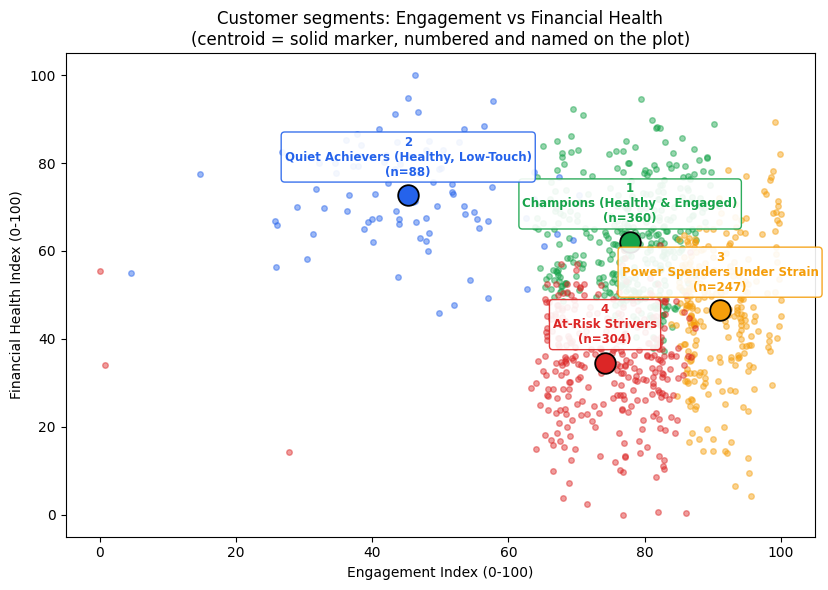

,count
segment_name,
1 — Champions (Healthy & Engaged),360
"2 — Quiet Achievers (Healthy, Low-Touch)",88
3 — Power Spenders Under Strain,247
4 — At-Risk Strivers,304


In [16]:
segment_names = {
    3: "1 — Champions (Healthy & Engaged)",
    1: "2 — Quiet Achievers (Healthy, Low-Touch)",
    2: "3 — Power Spenders Under Strain",
    0: "4 — At-Risk Strivers",
}  # numbered 1-4 by descending FinancialHealthIndex, purely for a stable reading order -- not a ranking of "value"
cust["segment_name"] = cust["cluster"].map(segment_names)

colors = {'1 — Champions (Healthy & Engaged)': '#16a34a',
          '2 — Quiet Achievers (Healthy, Low-Touch)': '#2563eb',
          '3 — Power Spenders Under Strain': '#f59e0b',
          '4 — At-Risk Strivers': '#dc2626'}

fig, ax = plt.subplots(figsize=(8.5, 6))
centroids = cust.groupby('segment_name')[['EngagementIndex', 'FinancialHealthIndex']].mean()
for seg, sub in cust.groupby('segment_name'):
    ax.scatter(sub['EngagementIndex'], sub['FinancialHealthIndex'], s=16, alpha=0.45,
               color=colors[seg], zorder=2)
# annotate cluster order + name directly on the plot, at each centroid
for seg, (ei, fhi) in centroids.iterrows():
    ax.scatter([ei], [fhi], s=220, color=colors[seg], edgecolor='black', linewidth=1.3, zorder=4)
    label_num = seg.split(' — ')[0]
    ax.annotate(f"{label_num}\n{seg.split(' — ')[1]}\n(n={sum(cust['segment_name']==seg)})",
                xy=(ei, fhi), xytext=(0, 14), textcoords='offset points',
                ha='center', fontsize=8.5, fontweight='bold', color=colors[seg],
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=colors[seg], alpha=0.9), zorder=5)
ax.set_xlabel('Engagement Index (0-100)')
ax.set_ylabel('Financial Health Index (0-100)')
ax.set_title('Customer segments: Engagement vs Financial Health\n(centroid = solid marker, numbered and named on the plot)')
fig.tight_layout()
plt.show()

cust["segment_name"].value_counts().sort_index()

**Cluster profiles (descriptive — for business to read the segments, not to act on them yet):**

- **1 — Champions (Healthy & Engaged), n=360, 36.0%:** highest balance growth of any segment, lowest spend-to-income ratio and utilization. Financially strong and actively using the product.
- **2 — Quiet Achievers (Healthy, Low-Touch), n=88, 8.8%:** lowest spend volatility of any segment, but by far the fewest transactions and active days, and the highest ratio of activity happening online rather than in person. Financially fine, just rarely present.
- **3 — Power Spenders Under Strain, n=247, 24.7%:** highest income and highest transaction volume of any segment, but also the highest spend volatility — high activity paired with less disciplined spending.
- **4 — At-Risk Strivers, n=304, 30.4%:** lowest financial health, highest spend-to-income ratio and utilization, and the *only* segment with a materially non-zero next-month low-health rate (2.0%) — this last figure was never used to build the clusters, so it serves as an external check that the grouping tracks real forward-looking risk.

These four descriptions are the deliverable for this section: what each group of customers actually looks like, in numbers business can act on independently.

### 3.1 Demographic profile of each segment

`age`, `gender`, `occupation` and `province_city` were kept in `cust` since Section 1.2 but never used as clustering inputs (Section 2 clusters only on financial/engagement behavior) — deliberately, so demographics can be used to *describe* each segment afterward without ever driving how it was built. This also doubles as a basic fairness check: whether an segment that might get targeted action later happens to concentrate in one age/gender/region group.

In [ ]:
order = ['1 — Champions (Healthy & Engaged)', '2 — Quiet Achievers (Healthy, Low-Touch)',
         '3 — Power Spenders Under Strain', '4 — At-Risk Strivers']

print("=== Age: summary stats by segment ===")
print(cust.groupby('segment_name')['age'].describe()[['mean', 'std', 'min', 'max']].reindex(order).round(1))

cust['age_bucket'] = pd.cut(cust['age'], bins=[14, 25, 35, 45, 55, 100],
                             labels=['18-25', '26-35', '36-45', '46-55', '56+'])
print("\n=== Age bucket distribution by segment (row %) ===")
print(pd.crosstab(cust['segment_name'], cust['age_bucket'], normalize='index').reindex(order).round(3))

print("\n=== Gender distribution by segment (row %) ===")
print(pd.crosstab(cust['segment_name'], cust['gender'], normalize='index').reindex(order).round(3))

top_provinces = cust['province_city'].value_counts().head(6).index
print("\n=== Top 6 provinces/cities by segment (row %) ===")
print(pd.crosstab(cust['segment_name'], cust['province_city'], normalize='index')[top_provinces].reindex(order).round(3))

print("\n`occupation` has", cust['occupation'].nunique(), "distinct values across", len(cust),
      "customers -- essentially unique per person, too granular for a direct crosstab; would need")
print("grouping into broader occupational categories before it can describe a segment meaningfully.")

**Reading the demographic profile:**
- **Gender** is fairly balanced everywhere except two segments lean noticeably: **Power Spenders Under Strain skew female (61.5%)** and **At-Risk Strivers skew male (57.2%)** — worth keeping in mind if any messaging is ever built around either segment.
- **Age is the most unevenly distributed variable.** Power Spenders Under Strain is the youngest segment (mean 41.9) and the most evenly spread across age bands. **Quiet Achievers is bimodal** — 20.5% are 18–25 and 64.8% are 56+, with **literally 0% in the 26–45 range** — i.e., this "low-touch" segment is really two different life stages (young customers not yet active + older customers who transact less) that a single segment name papers over.
- **Province/city** distribution is broadly similar across all four segments — no single region stands out as concentrated in any one segment.
- **Occupation could not be profiled directly** — 396 distinct values across 999 customers means it's essentially a free-text field, not a categorical one at this grain. Grouping it into broader job categories (e.g. office/service/technical/creative) would be needed before it could describe a segment or feed a fairness check; flagged again in Section 5.

This demographic split (particularly Quiet Achievers' bimodal age) is a genuine input for whoever eventually designs segment-specific outreach — even though, per the current scope, that design step itself is intentionally left out of this notebook.

## 4. Post-Segmentation Analysis

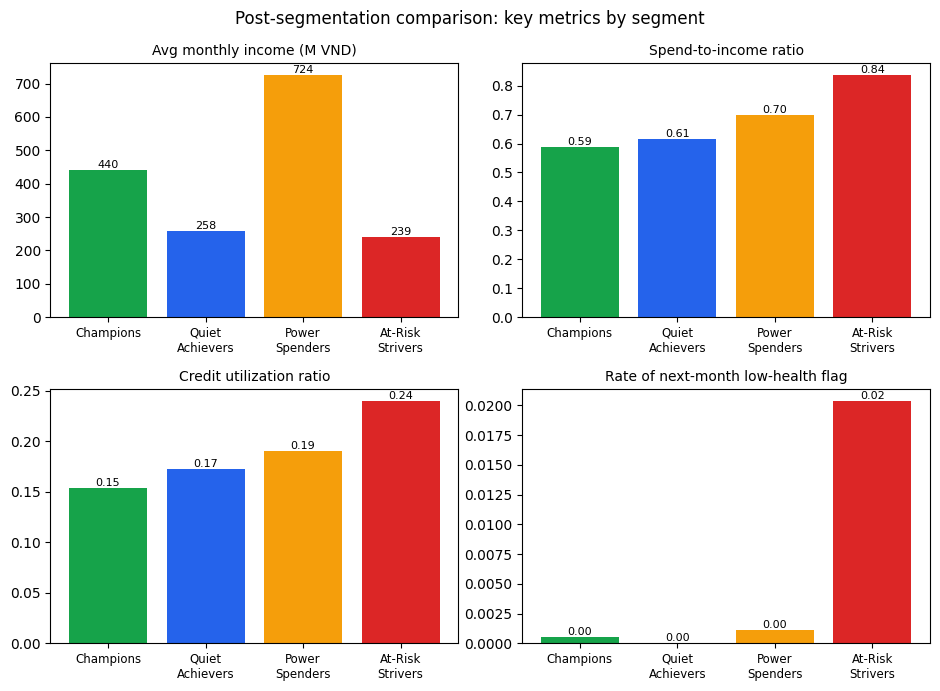

,avg_income,avg_spend_income_ratio,avg_utilization,low_health_rate
segment_name,,,,
1 — Champions (Healthy & Engaged),440.424,0.588,0.153,0.001
"2 — Quiet Achievers (Healthy, Low-Touch)",257.545,0.614,0.173,0.000
3 — Power Spenders Under Strain,724.321,0.699,0.191,0.001
4 — At-Risk Strivers,239.457,0.835,0.239,0.020


In [17]:
order = ['1 — Champions (Healthy & Engaged)', '2 — Quiet Achievers (Healthy, Low-Touch)',
         '3 — Power Spenders Under Strain', '4 — At-Risk Strivers']
metrics = {
    'avg_income': 'Avg monthly income (M VND)',
    'avg_spend_income_ratio': 'Spend-to-income ratio',
    'avg_utilization': 'Credit utilization ratio',
    'low_health_rate': 'Rate of next-month low-health flag'
}
prof = cust.groupby('segment_name')[list(metrics.keys())].mean().reindex(order)
prof['avg_income'] = prof['avg_income'] / 1e6

fig, axes = plt.subplots(2, 2, figsize=(9.5, 7))
short_labels = ['Champions', 'Quiet\nAchievers', 'Power\nSpenders', 'At-Risk\nStrivers']
for ax, (col, title) in zip(axes.flat, metrics.items()):
    bars = ax.bar(range(len(order)), prof[col], color=[colors[o] for o in order])
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(short_labels, fontsize=8.5)
    ax.set_title(title, fontsize=10)
    for b, v in zip(bars, prof[col]):
        ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.2f}' if v < 10 else f'{v:.0f}',
                ha='center', va='bottom', fontsize=8)
fig.suptitle('Post-segmentation comparison: key metrics by segment', fontsize=12)
fig.tight_layout()
plt.show()

prof.round(3)

**Key behavioral differences (descriptive only — no recommendations at this stage):**
- Income does not predict financial health — Power Spenders earn the most but rank near the bottom on health; Quiet Achievers earn the least but rank at the top.
- Engagement and health move independently — Champions and Power Spenders are both highly engaged, yet sit at different points on financial health; Quiet Achievers are healthy despite very low engagement.
- Forward-looking risk (`low_health_rate`) concentrates almost entirely in one segment — At-Risk Strivers — while the other three sit near zero.

## 5. Limitations and Future Work

### Technical limitations
1. **Static, cross-sectional representation:** each customer is reduced to a single 12-month-average vector, which removes trend/seasonality information entirely. Earlier experiments with linear trend features (`health_slope`, `engagement_slope`) were unsuccessful because OLS slopes on short per-customer histories are dominated by noise — a promising direction, implemented poorly.
2. **Unequal `n_months` not explicitly handled:** customers with fewer months of history (new or early-departing) have noisier `avg_*` features than customers with a full 12 months, but are clustered together without adjustment.
3. **Silhouette alone is not a reliable feature/parameter selector:** an earlier ablation test found that dropping certain features raised silhouette while collapsing cluster sizes into one dominant group plus fragments — the same failure mode this notebook's Section 2.2 block-weighting fix, and the rhythm-block test in Section 2.3, were built to catch. Silhouette must always be read together with cluster-size distribution.
4. **Transaction-level data is only partly incorporated.** Merchant category, geography, and channel from `consumer_transactions_2025.csv` are still unused. The rhythm features that *were* engineered (Section 1.6–2.3) were tested fairly and did not improve the primary segmentation, but remain available as descriptive/profiling columns.
5. **The transaction file itself has a data-quality defect** (Section 1.6): truncated at Excel's 1,048,576-row limit, cutting off months 9–12 and corrupting the datetime field. Any month-level "gap between transactions" feature is unreliable until the source file is re-exported directly to CSV without passing through Excel.
6. **Demographic fairness has not been evaluated:** `segment_name` has not been cross-tabulated with `occupation`, `province_city`, or `age` to check whether "At-Risk Strivers" concentrates disproportionately in one demographic group — necessary given the case study's own ethical-considerations note.
7. **K-Means assumes convex, similarly-sized clusters.** HDBSCAN (Section 2.6) confirms the population is largely one continuum, with a genuine density gap only around the low-engagement group — a reasonable, common situation for behavioral segmentation, but the 4 segments are a *chosen* partition, not 4 *discovered* populations.
8. **Cluster stability has not been tested** across random subsamples/bootstraps — only a single fit with `n_init=20`, without measuring Adjusted Rand Index across independent runs.
9. All financial magnitudes are synthetic per the dataset's own disclaimer.

### Suggested future work
- Model each customer's *trajectory* (robust trend estimation — e.g. Theil–Sen instead of OLS, computed only for customers with ≥6 months of history) instead of a single yearly average.
- Filter or flag low-`n_months` customers before they enter the main clustering process.
- Re-export the transaction file directly to CSV (bypassing Excel) to recover the 4 missing months and the real datetime field, then revisit the month-level "gap between transactions" features that were computed but excluded in Section 1.6.
- Engineer the remaining transaction-level features not yet tried (merchant diversity, geographic spread, channel mix) — the rhythm block's negative result doesn't rule these out.
- Run demographic fairness cross-tabs (`segment_name` × `occupation`/`province_city`/`age`) before any segment-specific action is taken.
- Try **GMM** for soft/probabilistic cluster assignment, better suited to HDBSCAN's continuum finding, with BIC/AIC as an additional criterion for the number of clusters.
- Perform bootstrap stability testing (K-Means on repeated 80% subsamples, Adjusted Rand Index across runs).
- Operationalize HDBSCAN's noise flag as a standing "atypical profile — manual review" list.
- Build a supervised early-warning model for `next_month_low_health_flag`, using the segment as one input.
- Re-run the segmentation periodically and track segment-migration rates as a KPI.

In [18]:
cust.to_csv("customer_segments.csv")
print("Saved customer_segments.csv —", cust.shape[0], "customers, 100% coverage.")

Saved customer_segments.csv — 999 customers, 100% coverage.
